<a href="https://colab.research.google.com/github/Nantakomar/TraigeLevel_Prediction/blob/main/Healthcare_Final_VIVA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CW2 Task 2 - Healthcare Triage ML Model

Dataset: synthetic_medical_triage.csv

Location: Google Drive / CW2_AI_Healthcare / Datasets

Tool: Google Colab with TensorFlow/Keras

Purpose: Build a simple ML component to classify patient triage priority.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/CW2_AI_Healthcare/Datasets/synthetic_medical_triage.csv"

df = pd.read_csv(file_path)

df.head()

,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (18000, 10)

Columns:
Index(['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation',
       'body_temperature', 'pain_level', 'chronic_disease_count',
       'previous_er_visits', 'arrival_mode', 'triage_level'],
      dtype='object')

Missing values:
age                        0
heart_rate                 0
systolic_blood_pressure    0
oxygen_saturation          0
body_temperature           0
pain_level                 0
chronic_disease_count      0
previous_er_visits         0
arrival_mode               0
triage_level               0
dtype: int64


In [ ]:
df['triage_level'].value_counts().sort_index()

,count
triage_level,
0,9924
1,4484
2,2701
3,891


In [ ]:
df['triage_level'].value_counts(normalize=True).sort_index() * 100

,proportion
triage_level,
0,55.133333
1,24.911111
2,15.005556
3,4.950000


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      18000 non-null  float64
 1   heart_rate               18000 non-null  float64
 2   systolic_blood_pressure  18000 non-null  float64
 3   oxygen_saturation        18000 non-null  float64
 4   body_temperature         18000 non-null  float64
 5   pain_level               18000 non-null  int64  
 6   chronic_disease_count    18000 non-null  int64  
 7   previous_er_visits       18000 non-null  int64  
 8   arrival_mode             18000 non-null  object 
 9   triage_level             18000 non-null  int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 1.4+ MB


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,triage_level
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,44.716244,83.292322,128.072739,96.085183,37.224236,3.402111,1.072611,1.265056,0.697722
std,19.101056,16.964405,18.813277,3.330830,0.914978,2.039249,1.312204,1.454887,0.898923
min,0.000000,33.400000,65.800000,79.500000,34.470000,1.000000,0.000000,0.000000,0.000000
25%,31.200000,71.500000,114.900000,94.300000,36.580000,2.000000,0.000000,0.000000,0.000000
50%,44.000000,81.600000,126.900000,96.600000,37.120000,3.000000,1.000000,1.000000,0.000000
75%,57.500000,93.200000,139.900000,98.700000,37.770000,5.000000,2.000000,2.000000,1.000000
max,95.000000,152.300000,219.700000,100.000000,41.130000,10.000000,10.000000,11.000000,3.000000


In [ ]:
df['arrival_mode'].value_counts()

,count
arrival_mode,
walk_in,11963
wheelchair,3067
ambulance,2970


In [ ]:
df_encoded = pd.get_dummies(df, columns=['arrival_mode'], dtype=int)

df_encoded.head()

,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,triage_level,arrival_mode_ambulance,arrival_mode_walk_in,arrival_mode_wheelchair
0,17.9,95.4,147.1,97.4,36.48,1,0,0,0,0,1,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,3,1,0,0
2,51.1,87.1,128.2,98.5,37.74,5,2,2,1,0,1,0
3,56.8,84.7,147.2,92.5,37.55,4,4,4,1,0,1,0
4,39.2,58.0,107.8,99.0,36.26,2,1,1,0,0,1,0


In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      18000 non-null  float64
 1   heart_rate               18000 non-null  float64
 2   systolic_blood_pressure  18000 non-null  float64
 3   oxygen_saturation        18000 non-null  float64
 4   body_temperature         18000 non-null  float64
 5   pain_level               18000 non-null  int64  
 6   chronic_disease_count    18000 non-null  int64  
 7   previous_er_visits       18000 non-null  int64  
 8   triage_level             18000 non-null  int64  
 9   arrival_mode_ambulance   18000 non-null  int64  
 10  arrival_mode_walk_in     18000 non-null  int64  
 11  arrival_mode_wheelchair  18000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 1.6 MB


In [ ]:
selected_features = [
    'age',
    'heart_rate',
    'systolic_blood_pressure',
    'oxygen_saturation',
    'body_temperature',
    'pain_level'
]

X = df_encoded[selected_features]
y = df_encoded['triage_level']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nSelected input features:")
print(X.columns.tolist())

print("\nTarget column:")
print(y.name)

X shape: (18000, 6)
y shape: (18000,)

Selected input features:
['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation', 'body_temperature', 'pain_level']

Target column:
triage_level


In [ ]:
# ============================================================
# REPRODUCIBILITY SETTINGS
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Make TensorFlow operations deterministic where possible
tf.config.experimental.enable_op_determinism()

print("Random seed fixed at:", SEED)

Random seed fixed at: 42


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing data
# stratify=y keeps the same triage level distribution in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the selected input features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

X_train shape: (14400, 6)
X_test shape: (3600, 6)
y_train shape: (14400,)
y_test shape: (3600,)

Training class distribution:
triage_level
0    55.131944
1    24.909722
2    15.006944
3     4.951389
Name: proportion, dtype: float64

Testing class distribution:
triage_level
0    55.138889
1    24.916667
2    15.000000
3     4.944444
Name: proportion, dtype: float64


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Clear any previous model from memory
tf.keras.backend.clear_session()

# Training parameters
learning_rate = 0.001
epochs = 50
batch_size = 32

# Build the neural network
model = keras.Sequential([
    layers.Input(shape=(6,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(4, activation="softmax")
])

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=learning_rate
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display architecture and parameters
model.summary()

print("Learning rate:", learning_rate)
print("Epochs:", epochs)
print("Batch size:", batch_size)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 284 (1.11 KB)

 Trainable params: 284 (1.11 KB)

 Non-trainable params: 0 (0.00 B)

Learning rate: 0.001
Epochs: 50
Batch size: 32


In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    verbose=1
)

Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7862 - loss: 0.6094 - val_accuracy: 0.8658 - val_loss: 0.3765
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8976 - loss: 0.3299 - val_accuracy: 0.9072 - val_loss: 0.2719
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9197 - loss: 0.2657 - val_accuracy: 0.9283 - val_loss: 0.2335
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9251 - loss: 0.2409 - val_accuracy: 0.9303 - val_loss: 0.2173
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9267 - loss: 0.2296 - val_accuracy: 0.9333 - val_loss: 0.2097
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9278 - loss: 0.2239 - val_accuracy: 0.9333 - val_loss: 0.2057
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9297 - loss: 0.2205 - val_accuracy: 0.9339 - val_loss: 0.2035
Epoch 8/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9301 - loss: 0.2184 - val_accuracy: 0.

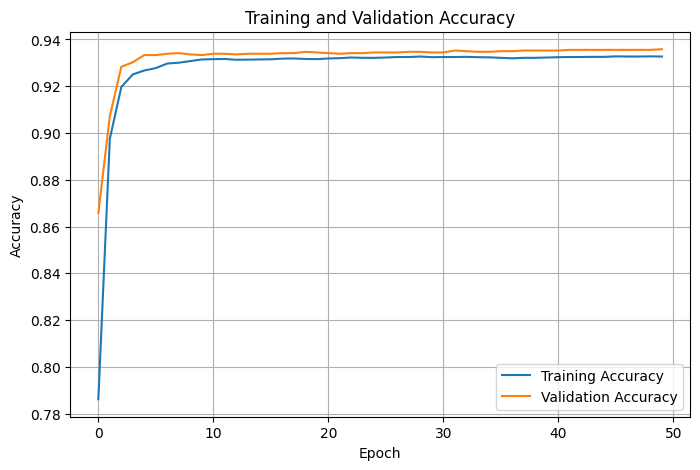

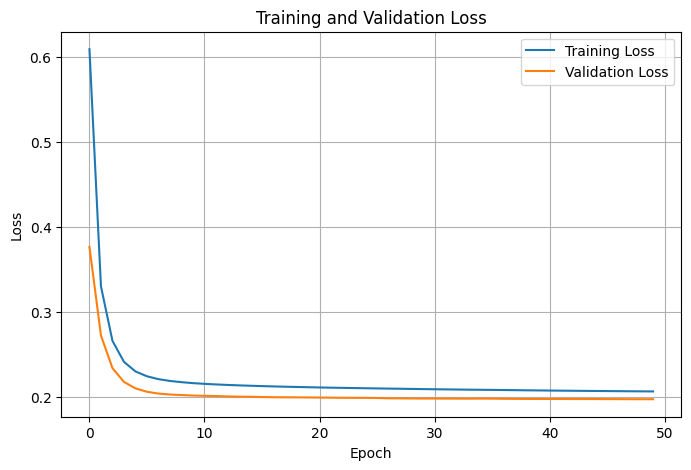

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test loss: 0.1969
Test accuracy: 93.58%


113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


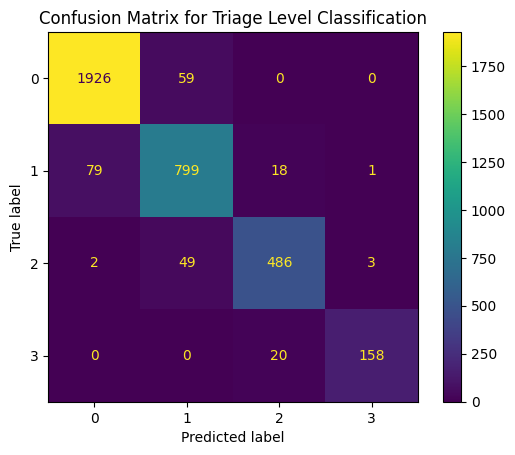

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict the test set
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])
disp.plot()
plt.title("Confusion Matrix for Triage Level Classification")
plt.show()

In [ ]:
# Example patient input for prediction
example_patient = pd.DataFrame([{
    'age': 70,
    'heart_rate': 125,
    'systolic_blood_pressure': 88,
    'oxygen_saturation': 89,
    'body_temperature': 39.2,
    'pain_level': 8
}])

# Scale the example patient using the same scaler
example_patient_scaled = scaler.transform(example_patient)

# Predict triage level
prediction_probabilities = model.predict(example_patient_scaled)
predicted_class = np.argmax(prediction_probabilities, axis=1)[0]

print("Example patient data:")
print(example_patient)

print("\nPrediction probabilities:")
print(prediction_probabilities)

print("\nPredicted triage level:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Example patient data:
   age  heart_rate  systolic_blood_pressure  oxygen_saturation  \
0   70         125                       88                 89   

   body_temperature  pain_level  
0              39.2           8  

Prediction probabilities:
[[1.1391522e-07 2.9228508e-05 2.2584036e-01 7.7413028e-01]]

Predicted triage level: 3


In [ ]:
import os
import joblib

# Folder in Google Drive
save_folder = "/content/drive/MyDrive/CW2_AI_Healthcare"

# Create the folder if it does not already exist
os.makedirs(save_folder, exist_ok=True)

# File locations
model_path = os.path.join(
    save_folder,
    "final_triage_model.keras"
)

scaler_path = os.path.join(
    save_folder,
    "final_scaler.pkl"
)

# Save the trained neural network
model.save(model_path)

# Save the fitted StandardScaler
joblib.dump(scaler, scaler_path)

print("Model saved successfully:")
print(model_path)

print("\nScaler saved successfully:")
print(scaler_path)

Model saved successfully:
/content/drive/MyDrive/CW2_AI_Healthcare/final_triage_model.keras

Scaler saved successfully:
/content/drive/MyDrive/CW2_AI_Healthcare/final_scaler.pkl


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import tensorflow as tf
import joblib

model_path = (
    "/content/drive/MyDrive/"
    "CW2_AI_Healthcare/"
    "final_triage_model.keras"
)

scaler_path = (
    "/content/drive/MyDrive/"
    "CW2_AI_Healthcare/"
    "final_scaler.pkl"
)

loaded_model = tf.keras.models.load_model(model_path)
loaded_scaler = joblib.load(scaler_path)

print("Saved model and scaler loaded successfully.")

Mounted at /content/drive
Saved model and scaler loaded successfully.


In [ ]:
import pandas as pd
import numpy as np

example_patient = pd.DataFrame([{
    "age": 70,
    "heart_rate": 125,
    "systolic_blood_pressure": 88,
    "oxygen_saturation": 89,
    "body_temperature": 39.2,
    "pain_level": 8
}])

example_scaled = loaded_scaler.transform(example_patient)

probabilities = loaded_model.predict(
    example_scaled,
    verbose=0
)[0]

predicted_level = int(np.argmax(probabilities))

for level, probability in enumerate(probabilities):
    print(f"Triage Level {level}: {probability:.2%}")

print("Predicted triage level:", predicted_level)

Triage Level 0: 0.00%
Triage Level 1: 0.00%
Triage Level 2: 22.58%
Triage Level 3: 77.41%
Predicted triage level: 3


In [ ]:
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 854 (3.34 KB)

 Trainable params: 284 (1.11 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 570 (2.23 KB)